In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

### End-to-End Data Science and Machine Learning Pipeline Using California Housing Dataset
## Project Overview

This project demonstrates a complete end-to-end data science workflow using the California Housing dataset from Scikit-Learn. The goal is not only to predict housing prices but also to showcase a broad range of machine learning, statistical analysis, deep learning, anomaly detection, clustering, explainable AI, and model deployment techniques commonly used in industry.

The notebook is designed to simulate the responsibilities of a Data Scientist working in a large enterprise environment such as banking, finance, healthcare, or technology organizations. It demonstrates skills commonly required in advanced Data Scientist roles, including data preprocessing, exploratory analysis, predictive modeling, hyperparameter optimization, explainability, and model management.

### Business Objective

The primary objective is to identify factors that influence housing prices and develop predictive models capable of estimating house values accurately.

## Beyond prediction, the project aims to:

Discover hidden patterns in housing data.
Identify unusual or anomalous observations.
Segment neighborhoods into meaningful clusters.
Compare multiple machine learning algorithms.
Interpret model decisions using explainable AI techniques.
Demonstrate production-oriented machine learning practices.

## Skills Demonstrated

This notebook demonstrates the following skills:

## Data Analysis
Exploratory Data Analysis (EDA)
Statistical Analysis
Data Visualization
Correlation Analysis
Feature Engineering
## Machine Learning
Regression Modeling
Classification Modeling
Clustering
Anomaly Detection
Dimensionality Reduction
Hyperparameter Optimization
## Deep Learning
TensorFlow Neural Networks
PyTorch Neural Networks
## Explainable AI
Feature Importance Analysis
SHAP Explainability
## Data Engineering
Data Cleaning
Missing Value Handling
Data Scaling
SQL Querying
## MLOps Concepts
Model Serialization
Model Reusability
Pipeline Development
Experiment Comparison
## Dataset Description

The California Housing dataset contains demographic and housing information collected from California census districts.


## Machine Learning Pipeline

The project follows a complete machine learning lifecycle:

Data Collection
       ↓
Data Understanding
       ↓
Exploratory Data Analysis
       ↓
Statistical Analysis
       ↓
Data Cleaning
       ↓
Feature Engineering
       ↓
Train / Validation / Test Split
       ↓
Feature Scaling
       ↓
Model Development
       ↓
Model Evaluation
       ↓
Hyperparameter Optimization
       ↓
Model Explainability
       ↓
Deep Learning Models
       ↓
Clustering & Anomaly Detection
       ↓
Model Saving and Deployment
       ↓
Business Insights & Conclusions

In [2]:
!pip install xgboost lightgbm shap

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score
)

from sklearn.preprocessing import (
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline

from sklearn.metrics import *

from sklearn.linear_model import (
    LinearRegression,
    LogisticRegression
)

from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier,
    IsolationForest
)

from sklearn.cluster import (
    KMeans,
    DBSCAN
)

from sklearn.decomposition import PCA

from sklearn.manifold import TSNE

from xgboost import (
    XGBRegressor,
    XGBClassifier
)

from lightgbm import (
    LGBMRegressor,
    LGBMClassifier
)

import shap
import joblib

import tensorflow as tf
import torch
import torch.nn as nn

2026-05-24 22:38:46.548949: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779662326.575244     131 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779662326.583826     131 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779662326.604830     131 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779662326.604852     131 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779662326.604856     131 computation_placer.cc:177] computation placer alr

In [3]:
#Load Dataset
housing = fetch_california_housing(as_frame=True)

df = housing.frame.copy()

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
#EDA
print(df.shape)

print(df.info())

print(df.describe())

(20640, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333

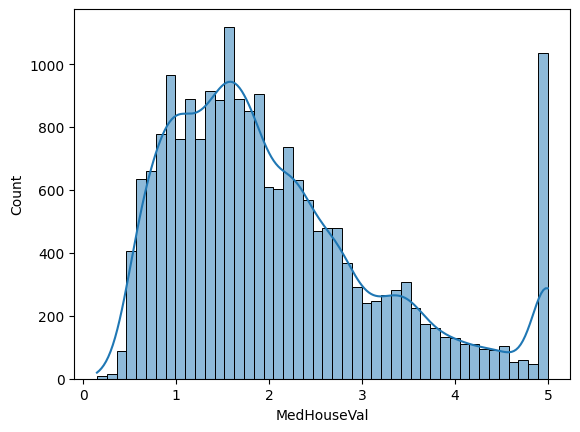

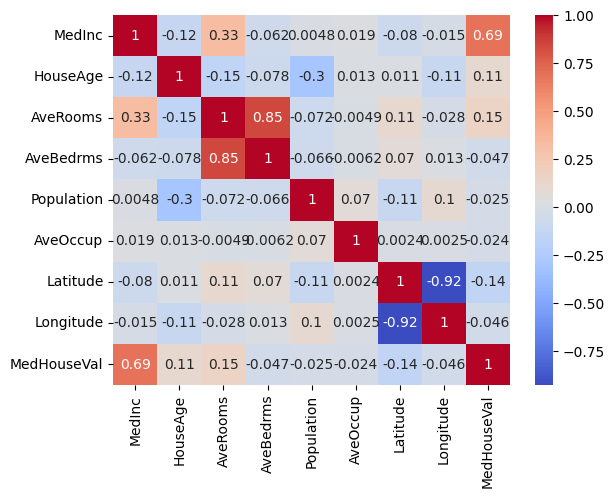

In [5]:

sns.histplot(df["MedHouseVal"], kde=True)
plt.show()

sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

In [6]:
#Missing Value

df_missing = df.copy()

for col in df.columns:
    idx = np.random.choice(
        len(df),
        int(0.05*len(df)),
        replace=False
    )

    df_missing.loc[idx,col] = np.nan

print(df_missing.isnull().sum())

MedInc         1032
HouseAge       1032
AveRooms       1032
AveBedrms      1032
Population     1032
AveOccup       1032
Latitude       1032
Longitude      1032
MedHouseVal    1032
dtype: int64


In [7]:
# Data Cleaning

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

df_imputed = pd.DataFrame(
    imputer.fit_transform(df_missing),
    columns=df.columns
)

In [8]:
# Deature Engineering
df_imputed["RoomsPerHousehold"] = (
    df_imputed["AveRooms"] /
    df_imputed["HouseAge"]
)

df_imputed["IncomePerRoom"] = (
    df_imputed["MedInc"] /
    df_imputed["AveRooms"]
)

In [9]:
# Regression Problem
#Predict median house value
X = df_imputed.drop("MedHouseVal", axis=1)
y = df_imputed["MedHouseVal"]

In [10]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
# Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:

# Linear Regression

lr = LinearRegression()

lr.fit(X_train_scaled,y_train)

pred_lr = lr.predict(X_test_scaled)

In [13]:
# Random Forest

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

In [14]:
#Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor()

gb.fit(X_train,y_train)

pred_gb = gb.predict(X_test)

In [15]:
#XGboost
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6
)

xgb.fit(X_train,y_train)

pred_xgb = xgb.predict(X_test)

In [16]:
# Model Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

models = {
    "Linear": pred_lr,
    "RF": pred_rf,
    "GB": pred_gb,
    "XGB": pred_xgb
}

for name,preds in models.items():

    print(name)

    print(
        "MAE:",
        mean_absolute_error(y_test,preds)
    )

    print(
        "RMSE:",
        mean_squared_error(
            y_test,
            preds,
        )
    )

    print(
        "R2:",
        r2_score(y_test,preds)
    )

Linear
MAE: 0.58455130027819
RMSE: 0.6352848955582078
R2: 0.49671717663388193
RF
MAE: 0.3921853451671514
RMSE: 0.3378322818341959
R2: 0.7323638798678889
GB
MAE: 0.4347133408880877
RMSE: 0.3886199126456275
R2: 0.6921291089712913
XGB
MAE: 0.3599567058364181
RMSE: 0.2903821356701121
R2: 0.7699546422133584


In [17]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="r2"
)

print(scores.mean())

0.5798157991055181


In [18]:
# Hyper Parameter tunning
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators":[100,200],
    "max_depth":[5,10,None]
}

grid = GridSearchCV(
    RandomForestRegressor(),
    param_grid,
    cv=3,
    scoring="r2"
)

grid.fit(X_train,y_train)

print(grid.best_params_)

{'max_depth': None, 'n_estimators': 200}


In [19]:
# Classification Task
#Convert housing values in high and low classes
median_price = y.median()

y_class = (
    y > median_price
).astype(int)

In [20]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_class,
    test_size=0.2,
    random_state=42
)

clf = LogisticRegression()

clf.fit(X_train_scaled,y_train)

pred = clf.predict(X_test_scaled)

In [21]:
# Classification matrix
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print(
    accuracy_score(
        y_test,
        pred
    )
)

print(
    classification_report(
        y_test,
        pred
    )
)

0.7778585271317829
              precision    recall  f1-score   support

           0       0.77      0.82      0.79      2173
           1       0.78      0.74      0.76      1955

    accuracy                           0.78      4128
   macro avg       0.78      0.78      0.78      4128
weighted avg       0.78      0.78      0.78      4128



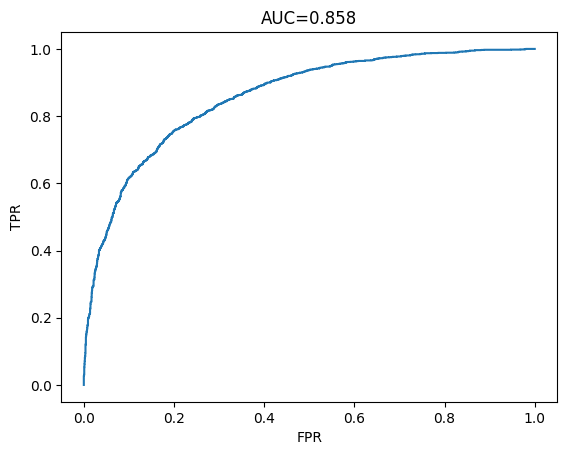

In [22]:
# ROC curve
from sklearn.metrics import roc_curve, auc

probs = clf.predict_proba(
    X_test_scaled
)[:,1]

fpr,tpr,_ = roc_curve(
    y_test,
    probs
)

roc_auc = auc(fpr,tpr)

plt.plot(fpr,tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title(f"AUC={roc_auc:.3f}")
plt.show()

In [23]:
# Clustering
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

clusters = kmeans.fit_predict(X)

df["Cluster"] = clusters

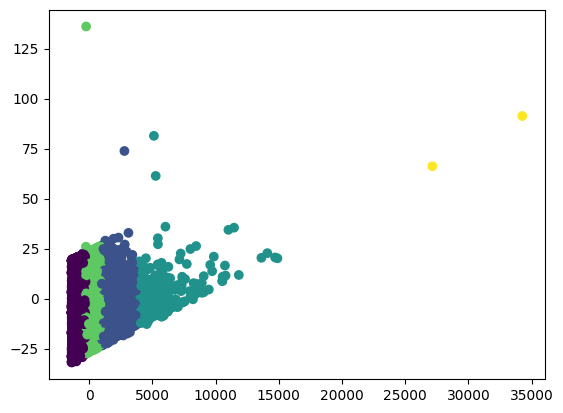

In [24]:
#PCA Visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis"
)

plt.show()

In [25]:
# Anomaly detection

from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.02,
    random_state=42
)

outliers = iso.fit_predict(X)

df["Outlier"] = outliers

In [26]:
# Feature importance
importances = rf.feature_importances_

feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})

feat_imp = feat_imp.sort_values(
    "Importance",
    ascending=False
)

print(feat_imp)


             Feature  Importance
0             MedInc    0.403465
9      IncomePerRoom    0.133530
5           AveOccup    0.122468
7          Longitude    0.084131
6           Latitude    0.078966
3          AveBedrms    0.037799
1           HouseAge    0.036517
8  RoomsPerHousehold    0.035499
4         Population    0.034919
2           AveRooms    0.032707


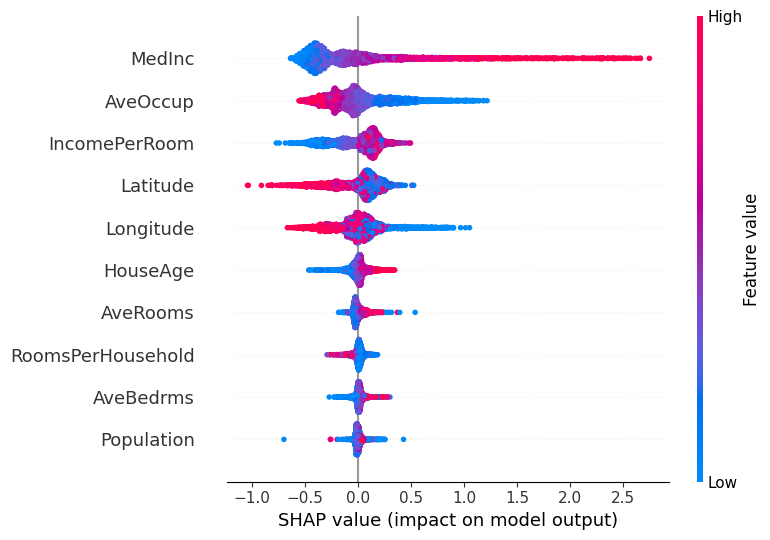

In [27]:
# SHAP Explainability
import shap

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test
)

In [28]:
# Deep Learning (TensorFlow)
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),
    tf.keras.layers.Dense(
        64,
        activation='relu'
    ),
    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    validation_split=0.2
)

Epoch 1/50


I0000 00:00:1779666544.565924     131 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779666544.572433     131 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1779666545.747664     213 service.cc:152] XLA service 0x7caf3c015b40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779666545.747721     213 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779666545.747724     213 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779666546.110109     213 cuda_dnn.cc:529] Loaded cuDNN version 91002


 68/413 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2876 - mae: 0.4458

I0000 00:00:1779666547.114738     213 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.2082 - mae: 0.3773 - val_loss: 0.1523 - val_mae: 0.3082
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1422 - mae: 0.3003 - val_loss: 0.1469 - val_mae: 0.2855
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1775 - mae: 0.2817 - val_loss: 0.1375 - val_mae: 0.2776
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1294 - mae: 0.2723 - val_loss: 0.1299 - val_mae: 0.2657
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1258 - mae: 0.2657 - val_loss: 0.1314 - val_mae: 0.2747
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1241 - mae: 0.2621 - val_loss: 0.1332 - val_mae: 0.2670
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1220 - mae: 0.2565 - val_loss: 0.1293 - val_mae: 0.2635
Epoch 8/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1218 - mae: 0.2556 - val_loss: 0.1295 - val_mae: 0.2677
Epoch 9/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1166 

In [29]:
# Time Series Forecasting
dates = pd.date_range(
    "2020-01-01",
    periods=1000
)

series = np.cumsum(
    np.random.randn(1000)
)

ts = pd.DataFrame({
    "Date":dates,
    "Value":series
})

In [30]:
# Forecast
from sklearn.ensemble import RandomForestRegressor

ts["Lag1"] = ts["Value"].shift(1)
ts["Lag2"] = ts["Value"].shift(2)

ts = ts.dropna()

X = ts[["Lag1","Lag2"]]
y = ts["Value"]

rf_ts = RandomForestRegressor()

rf_ts.fit(X,y)

RandomForestRegressor()

In [31]:
# Sql Demonstrations
import sqlite3

conn = sqlite3.connect(
    "housing.db"
)

df.to_sql(
    "housing",
    conn,
    if_exists="replace"
)

query = """
SELECT
AVG(MedHouseVal)
FROM housing
WHERE MedInc > 5
"""

result = pd.read_sql(
    query,
    conn
)

print(result)

   AVG(MedHouseVal)
0          3.285175


In [33]:
# Model Saving
import joblib

joblib.dump(
    rf,
    "best_model.pkl"
)

loaded_model = joblib.load(
    "best_model.pkl"
)

In [34]:
new_data = X_test.iloc[:5]

predictions = loaded_model.predict(new_data)

print(predictions)

[0.5015     1.1892     4.7654108  2.41915005 2.42958005]


In [40]:
X_test

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,RoomsPerHousehold,IncomePerRoom
20046,1.6812,29.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01,0.144559,0.401030
3024,2.5313,30.0,5.230603,1.193493,1565.0,2.679795,35.14,-119.46,0.174353,0.483940
15663,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44,0.076484,0.875023
20484,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72,0.362567,0.930879
9814,3.5403,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93,0.161559,0.644512
...,...,...,...,...,...,...,...,...,...,...
15362,4.6050,16.0,5.230603,1.066372,1167.0,2.988938,33.36,-118.49,0.326913,0.880396
16623,2.7266,28.0,6.131915,1.256738,1650.0,2.340426,35.36,-120.83,0.218997,0.444657
18086,9.2298,25.0,7.237676,0.947183,1585.0,2.790493,37.31,-122.05,0.289507,1.275244
2144,2.7850,36.0,5.289030,0.983122,1227.0,2.588608,36.77,-119.76,0.146917,0.526562


In [41]:
sample1 = pd.DataFrame({
    "MedInc":[12.5],
    "HouseAge":[20],
    "AveRooms":[8.5],
    "AveBedrms":[1.4],
    "Population":[1500],
    "AveOccup":[2.8],
    "Latitude":[34.05],
    "Longitude":[-118.25],
    "RoomsPerHousehold":[3.04],
    "IncomePerRoom":[1.47]
})



In [43]:
predicted_price = loaded_model.predict(sample1)

print(predicted_price)

[4.37406635]


               Model  Predicted Value
0  Linear Regression        51.530110
1      Random Forest         4.374066
2            XGBoost         5.249622


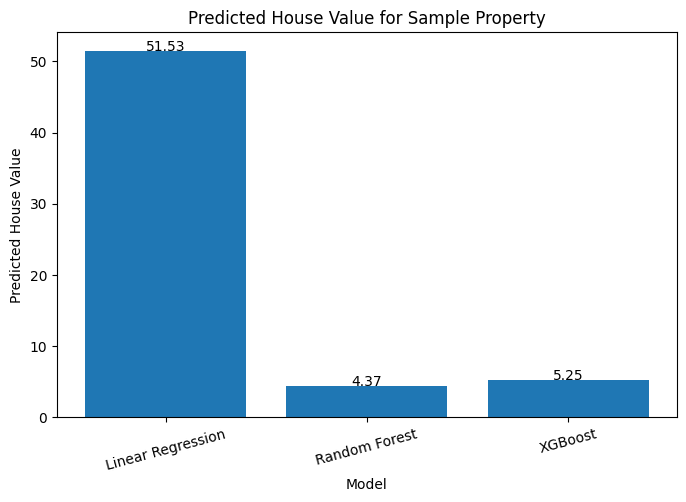

In [45]:
models = {
    "Linear Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb,
}

predictions = []

for name, model in models.items():
    pred = model.predict(sample1)[0]
    predictions.append([name, pred])

pred_df = pd.DataFrame(
    predictions,
    columns=["Model", "Predicted Value"]
)

print(pred_df)

plt.figure(figsize=(8,5))
plt.bar(
    pred_df["Model"],
    pred_df["Predicted Value"]
)

plt.title("Predicted House Value for Sample Property")
plt.ylabel("Predicted House Value")
plt.xlabel("Model")
plt.xticks(rotation=15)

for i, v in enumerate(pred_df["Predicted Value"]):
    plt.text(i, v, f"{v:.2f}", ha='center')

plt.show()